# Analyzing Sales Data in Alteryx

## 📖 Background
Test your Alteryx skills on four real-world datasets focusing on retail sales data. Using Alteryx Designer, you'll prepare, blend, and analyze data to answer questions about sales trends and performance. This will help you to identify key drivers of sales success, enabling informed business decisions and strategic planning.





## 💾 The data


The data consists of four tables:
- **Customer Orders-East**: individiual orders from Eastern states
- **Customer Orders-West**: individiual orders from Western states
- **Order details**: information on each order ID, including the sales price, number of items ordered, and the product category
- **Regions**: information on states and their corresponding region


## 💪 Challenge


 - What were the 10 most profitable orders?
 - What day of the week is most profitable, and by how much?
 - How do the profits vary by category and region?
 - What sub-categories contributed to the most profit in each category?


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
data_coe = pd.read_excel("Customer Orders-East.xlsx")
data_cow = pd.read_excel("Customer Orders-West.xlsx")
orders = pd.read_excel("Order Details.xlsx")
regions = pd.read_csv("Regions.csv")

In [17]:
data_coe.head()

,Order ID,Order Date,State,Name
0,B-25757,"August 21, 2023",Florida,Reynolds
1,B-26003,"February 08, 2023",Florida,Dunn
2,B-25797,"September 30, 2023",Florida,Wong
3,B-25639,"April 27, 2023",Florida,Cooper
4,B-25681,"June 04, 2023",Florida,Hunter


In [18]:
data_cow.head()

,Order ID,Order Date,CustomerName,State
0,B-25935,"January 04, 2023",Lambert,Arizona
1,B-25653,"May 08, 2023",Morris,Arizona
2,B-25671,"May 27, 2023",Howard,Arizona
3,B-25743,"August 07, 2023",Evans,Arizona
4,B-25635,"April 26, 2023",Richardson,Arizona


In [19]:
orders.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Order Quantities,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,Order ID,Sale Price,Cost per Item,Category,COD,Credit Card,Debit Card,EFT
1,B-25601,1275.00,18.14,Furniture - Bookcases,NaN,NaN,NaN,7
2,B-25601,66.00,15.60,Clothing - Scarf,NaN,NaN,NaN,5
3,B-25601,8.00,3.33,Clothing - Hat,3,NaN,NaN,NaN
4,B-25601,80.00,34.00,Electronics - Electronic Games,NaN,NaN,NaN,4


In [20]:
data_coe.columns = ['Order ID',	'Order Date',	'State', 'CustomerName']

In [21]:
data_coe.head()

,Order ID,Order Date,State,CustomerName
0,B-25757,"August 21, 2023",Florida,Reynolds
1,B-26003,"February 08, 2023",Florida,Dunn
2,B-25797,"September 30, 2023",Florida,Wong
3,B-25639,"April 27, 2023",Florida,Cooper
4,B-25681,"June 04, 2023",Florida,Hunter


In [22]:
data_coe["Order Date"] = pd.to_datetime(data_coe["Order Date"], errors="coerce")
data_cow["Order Date"] = pd.to_datetime(data_cow["Order Date"], errors="coerce")

In [23]:
data_coe["Sales Zone"] = "East"
data_cow["Sales Zone"] = "West"

In [24]:
data_coe.head()

,Order ID,Order Date,State,CustomerName,Sales Zone
0,B-25757,2023-08-21,Florida,Reynolds,East
1,B-26003,2023-02-08,Florida,Dunn,East
2,B-25797,2023-09-30,Florida,Wong,East
3,B-25639,2023-04-27,Florida,Cooper,East
4,B-25681,2023-06-04,Florida,Hunter,East


In [25]:
data_cow.head()

,Order ID,Order Date,CustomerName,State,Sales Zone
0,B-25935,2023-01-04,Lambert,Arizona,West
1,B-25653,2023-05-08,Morris,Arizona,West
2,B-25671,2023-05-27,Howard,Arizona,West
3,B-25743,2023-08-07,Evans,Arizona,West
4,B-25635,2023-04-26,Richardson,Arizona,West


In [26]:
customer_orders = pd.concat([data_coe, data_cow], ignore_index=True)

In [27]:
customer_orders.head()

,Order ID,Order Date,State,CustomerName,Sales Zone
0,B-25757,2023-08-21,Florida,Reynolds,East
1,B-26003,2023-02-08,Florida,Dunn,East
2,B-25797,2023-09-30,Florida,Wong,East
3,B-25639,2023-04-27,Florida,Cooper,East
4,B-25681,2023-06-04,Florida,Hunter,East


In [28]:
regions["State"] = regions["State"].str.strip()
regions["Region"] = regions["Region"].str.strip()


In [29]:
customer_orders = customer_orders.merge(
    regions,
    on="State",
    how="left"
)

In [30]:
customer_orders.head()

,Order ID,Order Date,State,CustomerName,Sales Zone,Region
0,B-25757,2023-08-21,Florida,Reynolds,East,Southeast
1,B-26003,2023-02-08,Florida,Dunn,East,Southeast
2,B-25797,2023-09-30,Florida,Wong,East,Southeast
3,B-25639,2023-04-27,Florida,Cooper,East,Southeast
4,B-25681,2023-06-04,Florida,Hunter,East,Southeast


In [31]:
customer_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      525 non-null    object        
 1   Order Date    525 non-null    datetime64[ns]
 2   State         525 non-null    object        
 3   CustomerName  525 non-null    object        
 4   Sales Zone    525 non-null    object        
 5   Region        525 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 24.7+ KB


In [32]:
orders.columns = orders.iloc[0]
orders = orders.drop(index=0).reset_index(drop=True)


In [33]:
orders.head()

,Order ID,Sale Price,Cost per Item,Category,COD,Credit Card,Debit Card,EFT
0,B-25601,1275.00,18.14,Furniture - Bookcases,NaN,NaN,NaN,7
1,B-25601,66.00,15.60,Clothing - Scarf,NaN,NaN,NaN,5
2,B-25601,8.00,3.33,Clothing - Hat,3,NaN,NaN,NaN
3,B-25601,80.00,34.00,Electronics - Electronic Games,NaN,NaN,NaN,4
4,B-25602,119.00,15.50,Clothing - Dress,8,NaN,NaN,NaN


In [34]:
num_cols = ["Sale Price", "Cost per Item", "COD", "Credit Card", "Debit Card", "EFT"]

for col in num_cols:
    orders[col] = pd.to_numeric(orders[col], errors="coerce")


In [35]:
payment_cols = ["COD", "Credit Card", "Debit Card", "EFT"]

orders_long = orders.melt(
    id_vars=["Order ID", "Sale Price", "Cost per Item", "Category"],
    value_vars=payment_cols,
    var_name="Payment Method",
    value_name="Order Quantity"
)


In [36]:
orders_long = orders_long.dropna(subset=["Order Quantity"])


In [37]:
orders_long["Revenue"] = orders_long["Sale Price"] * orders_long["Order Quantity"]
orders_long["Cost"] = orders_long["Cost per Item"] * orders_long["Order Quantity"]
orders_long["Profit"] = orders_long["Revenue"] - orders_long["Cost"]


In [38]:
orders_long.head()

,Order ID,Sale Price,Cost per Item,Category,Payment Method,Order Quantity,Revenue,Cost,Profit
2,B-25601,8.0,3.33,Clothing - Hat,COD,3.0,24.0,9.99,14.01
4,B-25602,119.0,15.50,Clothing - Dress,COD,8.0,952.0,124.00,828.00
6,B-25602,2617.0,366.50,Electronics - Phones,COD,4.0,10468.0,1466.00,9002.00
22,B-25608,1364.0,-100.00,Furniture - Tables,COD,5.0,6820.0,-500.00,7320.00
36,B-25613,1603.0,178.11,Clothing - Dress,COD,9.0,14427.0,1602.99,12824.01


In [39]:
orders_long.isna().sum()

Order ID          0
Sale Price        0
Cost per Item     0
Category          0
Payment Method    0
Order Quantity    0
Revenue           0
Cost              0
Profit            0
dtype: int64

In [40]:
fact_sales = orders_long.merge(
    customer_orders,
    on="Order ID",
    how="left"
)


In [41]:
fact_sales["Main Category"] = fact_sales["Category"].str.split(" - ").str[0]

fact_sales["Sub Category"] = fact_sales["Category"].str.split(" - ").str[1]


In [42]:
fact_sales.head()

,Order ID,Sale Price,Cost per Item,Category,Payment Method,Order Quantity,Revenue,Cost,Profit,Order Date,State,CustomerName,Sales Zone,Region,Main Category,Sub Category
0,B-25601,8.0,3.33,Clothing - Hat,COD,3.0,24.0,9.99,14.01,2023-04-01,Pennsylvania,White,East,Northeast,Clothing,Hat
1,B-25602,119.0,15.50,Clothing - Dress,COD,8.0,952.0,124.00,828.00,2023-04-01,California,Hamilton,West,West,Clothing,Dress
2,B-25602,2617.0,366.50,Electronics - Phones,COD,4.0,10468.0,1466.00,9002.00,2023-04-01,California,Hamilton,West,West,Electronics,Phones
3,B-25608,1364.0,-100.00,Furniture - Tables,COD,5.0,6820.0,-500.00,7320.00,2023-04-08,Wisconsin,Wilson,West,Midwest,Furniture,Tables
4,B-25613,1603.0,178.11,Clothing - Dress,COD,9.0,14427.0,1602.99,12824.01,2023-04-12,Tennessee,Ward,East,Southeast,Clothing,Dress


In [43]:
fact_sales = fact_sales.drop(columns=["Category"])


In [44]:
fact_sales.head()

,Order ID,Sale Price,Cost per Item,Payment Method,Order Quantity,Revenue,Cost,Profit,Order Date,State,CustomerName,Sales Zone,Region,Main Category,Sub Category
0,B-25601,8.0,3.33,COD,3.0,24.0,9.99,14.01,2023-04-01,Pennsylvania,White,East,Northeast,Clothing,Hat
1,B-25602,119.0,15.50,COD,8.0,952.0,124.00,828.00,2023-04-01,California,Hamilton,West,West,Clothing,Dress
2,B-25602,2617.0,366.50,COD,4.0,10468.0,1466.00,9002.00,2023-04-01,California,Hamilton,West,West,Electronics,Phones
3,B-25608,1364.0,-100.00,COD,5.0,6820.0,-500.00,7320.00,2023-04-08,Wisconsin,Wilson,West,Midwest,Furniture,Tables
4,B-25613,1603.0,178.11,COD,9.0,14427.0,1602.99,12824.01,2023-04-12,Tennessee,Ward,East,Southeast,Clothing,Dress


In [45]:
print("fact_sales",fact_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1587 non-null   object        
 1   Sale Price      1587 non-null   float64       
 2   Cost per Item   1587 non-null   float64       
 3   Payment Method  1587 non-null   object        
 4   Order Quantity  1587 non-null   float64       
 5   Revenue         1587 non-null   float64       
 6   Cost            1587 non-null   float64       
 7   Profit          1587 non-null   float64       
 8   Order Date      1587 non-null   datetime64[ns]
 9   State           1587 non-null   object        
 10  CustomerName    1587 non-null   object        
 11  Sales Zone      1587 non-null   object        
 12  Region          1587 non-null   object        
 13  Main Category   1587 non-null   object        
 14  Sub Category    1587 non-null   object        
dtypes: d

In [46]:
fact_sales = fact_sales[
    [
        "Order ID",
        "Order Date",
        "CustomerName",
        "State",
        "Sales Zone",
        "Main Category",
        "Sub Category",
        "Payment Method",
        "Order Quantity",
        "Sale Price",
        "Revenue",
        "Cost",
        "Profit"
    ]
]


In [47]:
fact_sales

,Order ID,Order Date,CustomerName,State,Sales Zone,Main Category,Sub Category,Payment Method,Order Quantity,Sale Price,Revenue,Cost,Profit
0,B-25601,2023-04-01,White,Pennsylvania,East,Clothing,Hat,COD,3.0,8.0,24.0,9.99,14.01
1,B-25602,2023-04-01,Hamilton,California,West,Clothing,Dress,COD,8.0,119.0,952.0,124.00,828.00
2,B-25602,2023-04-01,Hamilton,California,West,Electronics,Phones,COD,4.0,2617.0,10468.0,1466.00,9002.00
3,B-25608,2023-04-08,Wilson,Wisconsin,West,Furniture,Tables,COD,5.0,1364.0,6820.0,-500.00,7320.00
4,B-25613,2023-04-12,Ward,Tennessee,East,Clothing,Dress,COD,9.0,1603.0,14427.0,1602.99,12824.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1582,B-26097,2023-03-28,Roberts,Michigan,West,Clothing,Hat,EFT,2.0,97.0,194.0,85.00,109.00
1583,B-26098,2023-03-29,King,Missouri,West,Clothing,T,EFT,2.0,59.0,118.0,44.00,74.00
1584,B-26098,2023-03-29,King,Missouri,West,Electronics,Accessories,EFT,3.0,82.0,246.0,74.01,171.99
1585,B-26098,2023-03-29,King,Missouri,West,Clothing,Leggings,EFT,5.0,96.0,480.0,144.00,336.00


In [48]:
fact_sales["Profit Margin %"] = (fact_sales["Profit"] / fact_sales["Revenue"]) * 100


In [49]:
fact_sales.head()

,Order ID,Order Date,CustomerName,State,Sales Zone,Main Category,Sub Category,Payment Method,Order Quantity,Sale Price,Revenue,Cost,Profit,Profit Margin %
0,B-25601,2023-04-01,White,Pennsylvania,East,Clothing,Hat,COD,3.0,8.0,24.0,9.99,14.01,58.375000
1,B-25602,2023-04-01,Hamilton,California,West,Clothing,Dress,COD,8.0,119.0,952.0,124.00,828.00,86.974790
2,B-25602,2023-04-01,Hamilton,California,West,Electronics,Phones,COD,4.0,2617.0,10468.0,1466.00,9002.00,85.995415
3,B-25608,2023-04-08,Wilson,Wisconsin,West,Furniture,Tables,COD,5.0,1364.0,6820.0,-500.00,7320.00,107.331378
4,B-25613,2023-04-12,Ward,Tennessee,East,Clothing,Dress,COD,9.0,1603.0,14427.0,1602.99,12824.01,88.888958


In [50]:
fact_sales["Year"] = fact_sales["Order Date"].dt.year
fact_sales["Month"] = fact_sales["Order Date"].dt.month
fact_sales["Month Name"] = fact_sales["Order Date"].dt.month_name()
fact_sales["Quarter"] = fact_sales["Order Date"].dt.to_period("Q").astype(str)


In [51]:
fact_sales.head()

,Order ID,Order Date,CustomerName,State,Sales Zone,Main Category,Sub Category,Payment Method,Order Quantity,Sale Price,Revenue,Cost,Profit,Profit Margin %,Year,Month,Month Name,Quarter
0,B-25601,2023-04-01,White,Pennsylvania,East,Clothing,Hat,COD,3.0,8.0,24.0,9.99,14.01,58.375000,2023,4,April,2023Q2
1,B-25602,2023-04-01,Hamilton,California,West,Clothing,Dress,COD,8.0,119.0,952.0,124.00,828.00,86.974790,2023,4,April,2023Q2
2,B-25602,2023-04-01,Hamilton,California,West,Electronics,Phones,COD,4.0,2617.0,10468.0,1466.00,9002.00,85.995415,2023,4,April,2023Q2
3,B-25608,2023-04-08,Wilson,Wisconsin,West,Furniture,Tables,COD,5.0,1364.0,6820.0,-500.00,7320.00,107.331378,2023,4,April,2023Q2
4,B-25613,2023-04-12,Ward,Tennessee,East,Clothing,Dress,COD,9.0,1603.0,14427.0,1602.99,12824.01,88.888958,2023,4,April,2023Q2


In [52]:
fact_sales.duplicated().sum()


0

In [53]:
order_level = fact_sales.groupby("Order ID").agg(
    Order_Revenue=("Revenue", "sum"),
    Order_Profit=("Profit", "sum"),
    Items_Per_Order=("Order Quantity", "sum")
).reset_index()

fact_sales = fact_sales.merge(order_level, on="Order ID", how="left")


In [54]:
fact_sales.head()

,Order ID,Order Date,CustomerName,State,Sales Zone,Main Category,Sub Category,Payment Method,Order Quantity,Sale Price,...,Cost,Profit,Profit Margin %,Year,Month,Month Name,Quarter,Order_Revenue,Order_Profit,Items_Per_Order
0,B-25601,2023-04-01,White,Pennsylvania,East,Clothing,Hat,COD,3.0,8.0,...,9.99,14.01,58.375000,2023,4,April,2023Q2,9599.0,9248.03,19.0
1,B-25602,2023-04-01,Hamilton,California,West,Clothing,Dress,COD,8.0,119.0,...,124.00,828.00,86.974790,2023,4,April,2023Q2,15559.0,12645.01,22.0
2,B-25602,2023-04-01,Hamilton,California,West,Electronics,Phones,COD,4.0,2617.0,...,1466.00,9002.00,85.995415,2023,4,April,2023Q2,15559.0,12645.01,22.0
3,B-25608,2023-04-08,Wilson,Wisconsin,West,Furniture,Tables,COD,5.0,1364.0,...,-500.00,7320.00,107.331378,2023,4,April,2023Q2,14669.0,13987.99,19.0
4,B-25613,2023-04-12,Ward,Tennessee,East,Clothing,Dress,COD,9.0,1603.0,...,1602.99,12824.01,88.888958,2023,4,April,2023Q2,14427.0,12824.01,9.0


In [55]:
customer_order_count = (
    fact_sales.groupby("CustomerName")["Order ID"]
    .nunique()
    .reset_index(name="Order_Count")
)

fact_sales = fact_sales.merge(customer_order_count, on="CustomerName", how="left")

fact_sales["Customer Type"] = np.where(
    fact_sales["Order_Count"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)


In [56]:
fact_sales.head()

,Order ID,Order Date,CustomerName,State,Sales Zone,Main Category,Sub Category,Payment Method,Order Quantity,Sale Price,...,Profit Margin %,Year,Month,Month Name,Quarter,Order_Revenue,Order_Profit,Items_Per_Order,Order_Count,Customer Type
0,B-25601,2023-04-01,White,Pennsylvania,East,Clothing,Hat,COD,3.0,8.0,...,58.375000,2023,4,April,2023Q2,9599.0,9248.03,19.0,3,Repeat Customer
1,B-25602,2023-04-01,Hamilton,California,West,Clothing,Dress,COD,8.0,119.0,...,86.974790,2023,4,April,2023Q2,15559.0,12645.01,22.0,2,Repeat Customer
2,B-25602,2023-04-01,Hamilton,California,West,Electronics,Phones,COD,4.0,2617.0,...,85.995415,2023,4,April,2023Q2,15559.0,12645.01,22.0,2,Repeat Customer
3,B-25608,2023-04-08,Wilson,Wisconsin,West,Furniture,Tables,COD,5.0,1364.0,...,107.331378,2023,4,April,2023Q2,14669.0,13987.99,19.0,3,Repeat Customer
4,B-25613,2023-04-12,Ward,Tennessee,East,Clothing,Dress,COD,9.0,1603.0,...,88.888958,2023,4,April,2023Q2,14427.0,12824.01,9.0,2,Repeat Customer


In [57]:
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         1587 non-null   object        
 1   Order Date       1587 non-null   datetime64[ns]
 2   CustomerName     1587 non-null   object        
 3   State            1587 non-null   object        
 4   Sales Zone       1587 non-null   object        
 5   Main Category    1587 non-null   object        
 6   Sub Category     1587 non-null   object        
 7   Payment Method   1587 non-null   object        
 8   Order Quantity   1587 non-null   float64       
 9   Sale Price       1587 non-null   float64       
 10  Revenue          1587 non-null   float64       
 11  Cost             1587 non-null   float64       
 12  Profit           1587 non-null   float64       
 13  Profit Margin %  1587 non-null   float64       
 14  Year             1587 non-null   int32  

# Data Visualizations 

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("talk")


### What were the 10 most profitable orders?

In [59]:
top_10_orders = (
    fact_sales
    .groupby("Order ID", as_index=False)
    .agg(
        Order_Profit=("Profit", "sum"),
        Order_Revenue=("Revenue", "sum"),
        Items=("Order Quantity", "sum")
    )
    .sort_values("Order_Profit", ascending=False)
    .head(10)
)

top_10_orders


,Order ID,Order_Profit,Order_Revenue,Items
454,B-26055,186584.02,206702.0,114.0
372,B-25973,121928.08,128444.0,80.0
280,B-25881,45037.96,55856.0,46.0
354,B-25955,37235.96,42906.0,46.0
197,B-25798,33256.96,38896.0,26.0
160,B-25761,30168.04,34878.0,56.0
257,B-25858,27909.97,30640.0,34.0
492,B-26093,25533.96,29098.0,28.0
52,B-25653,24466.91,29307.0,45.0
392,B-25993,22336.97,27499.0,25.0


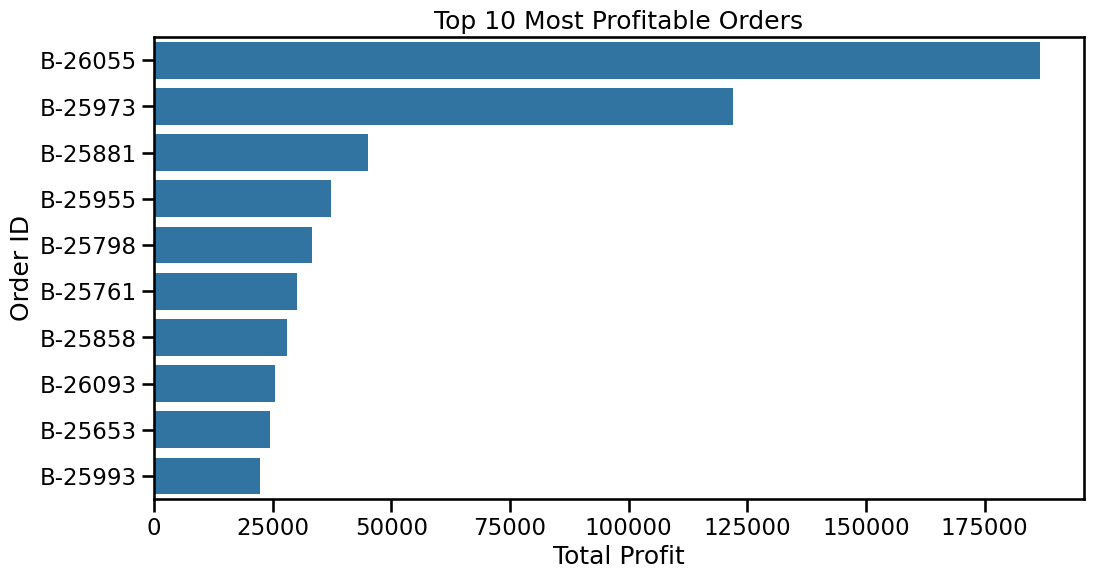

In [60]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_orders,
    x="Order_Profit",
    y="Order ID"
)
plt.title("Top 10 Most Profitable Orders")
plt.xlabel("Total Profit")
plt.ylabel("Order ID")
plt.show()


### 2️⃣ What day of the week is most profitable?

In [61]:
fact_sales["Day Name"] = fact_sales["Order Date"].dt.day_name()


In [62]:
day_profit = (
    fact_sales
    .groupby("Day Name", as_index=False)
    .agg(Total_Profit=("Profit", "sum"))
)

# Correct weekday order
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
day_profit["Day Name"] = pd.Categorical(
    day_profit["Day Name"],
    categories=day_order,
    ordered=True
)

day_profit = day_profit.sort_values("Day Name")
day_profit


,Day Name,Total_Profit
1,Monday,295741.76
5,Tuesday,276149.80
6,Wednesday,268195.91
4,Thursday,222658.75
0,Friday,419857.02
2,Saturday,308182.83
3,Sunday,228442.78


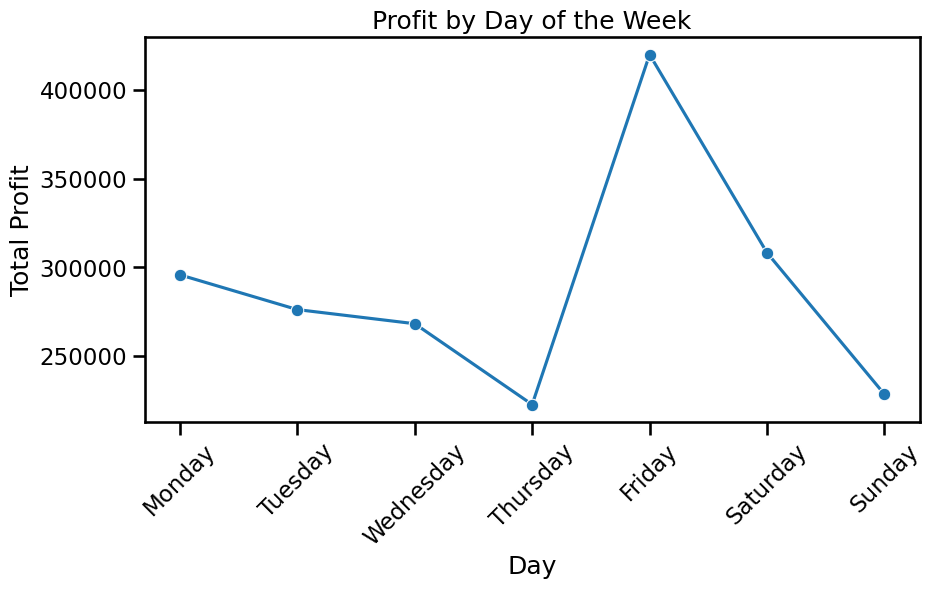

In [63]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=day_profit,
    x="Day Name",
    y="Total_Profit",
    marker="o"
)
plt.title("Profit by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()


In [64]:
most_profitable_day = day_profit.loc[
    day_profit["Total_Profit"].idxmax()
]
most_profitable_day


Day Name           Friday
Total_Profit    419857.02
Name: 0, dtype: object

### 3️⃣ How do profits vary by Category and Region (Sales Zone)?

In [65]:
category_zone_profit = (
    fact_sales
    .groupby(["Sales Zone", "Main Category"], as_index=False)
    .agg(Total_Profit=("Profit", "sum"))
)


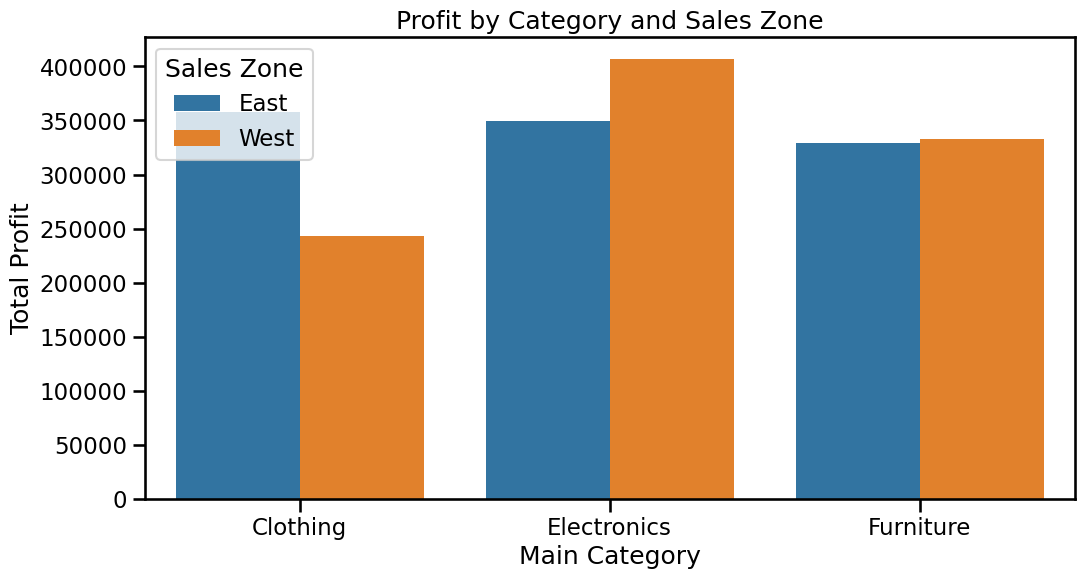

In [66]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=category_zone_profit,
    x="Main Category",
    y="Total_Profit",
    hue="Sales Zone"
)
plt.title("Profit by Category and Sales Zone")
plt.xlabel("Main Category")
plt.ylabel("Total Profit")
plt.legend(title="Sales Zone")
plt.show()


### 4️⃣ Which sub-categories contributed most profit within each category?

In [67]:
subcat_profit = (
    fact_sales
    .groupby(["Main Category", "Sub Category"], as_index=False)
    .agg(Total_Profit=("Profit", "sum"))
)


In [68]:
top_subcats = (
    subcat_profit
    .sort_values(["Main Category", "Total_Profit"], ascending=[True, False])
    .groupby("Main Category")
    .head(3)
)

top_subcats


,Main Category,Sub Category,Total_Profit
0,Clothing,Dress,241062.82
3,Clothing,Pants,106047.00
4,Clothing,Scarf,80306.11
11,Electronics,Printers,323551.87
9,Electronics,Electronic Games,177057.86
10,Electronics,Phones,164680.98
12,Furniture,Bookcases,272248.96
13,Furniture,Chairs,257784.98
15,Furniture,Tables,72284.96


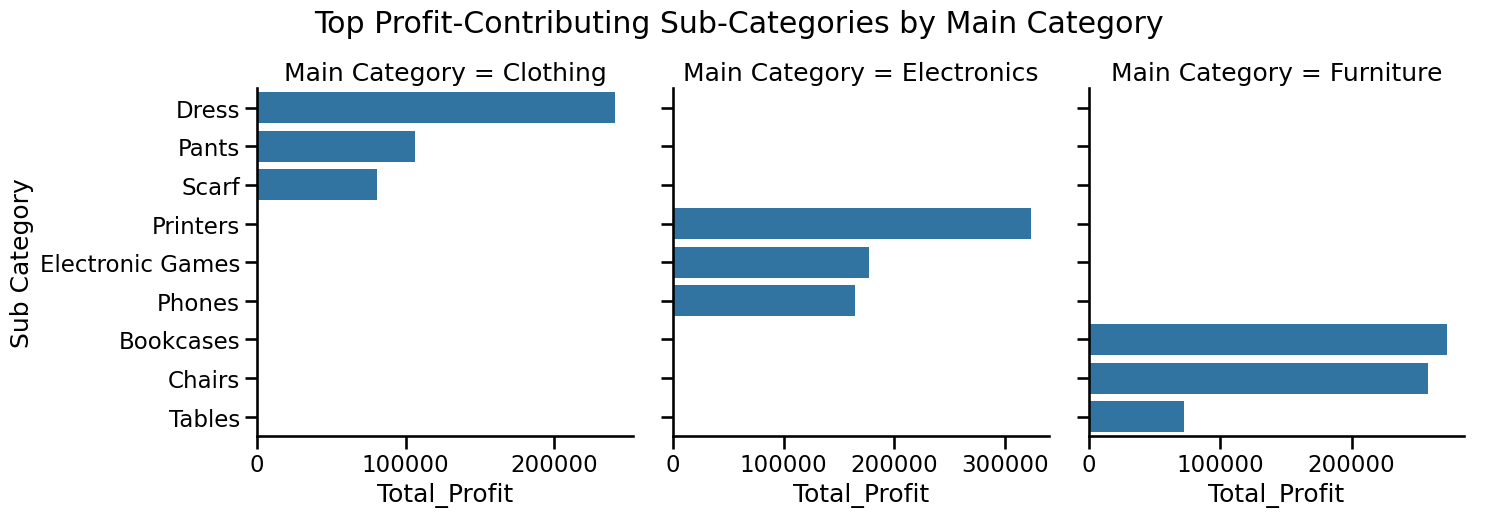

In [69]:
g = sns.catplot(
    data=top_subcats,
    x="Total_Profit",
    y="Sub Category",
    col="Main Category",
    kind="bar",
    col_wrap=3,
    height=5,
    sharex=False
)

g.fig.suptitle("Top Profit-Contributing Sub-Categories by Main Category", y=1.05)
plt.show()


#### Profit Margin vs Revenue – Category Tradeoff

In [70]:
category_margin = (
    fact_sales
    .groupby("Main Category", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum")
    )
)

category_margin["Profit Margin %"] = (
    category_margin["Profit"] / category_margin["Revenue"] * 100
)


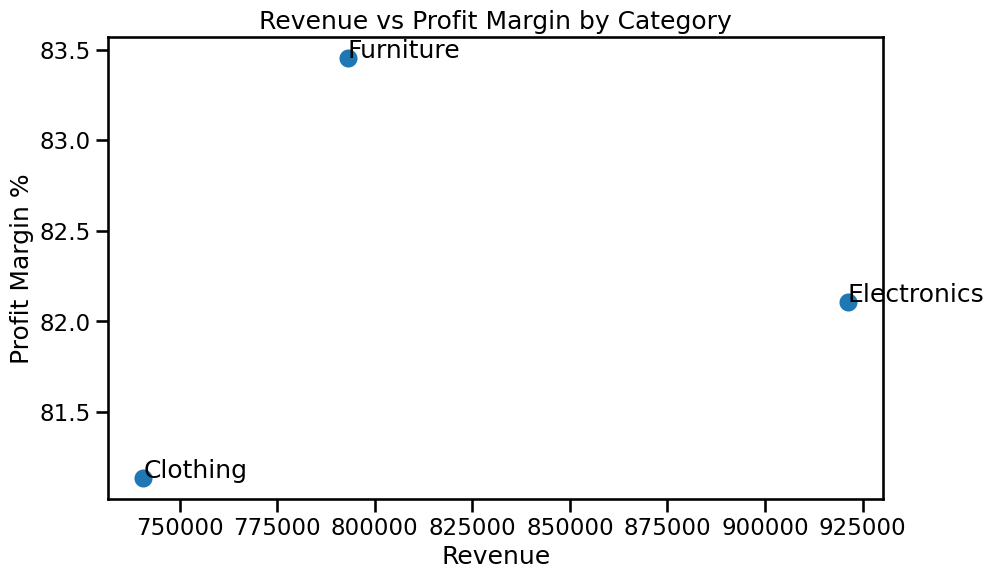

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=category_margin,
    x="Revenue",
    y="Profit Margin %",
    s=200
)
for i in range(len(category_margin)):
    plt.text(
        category_margin["Revenue"][i],
        category_margin["Profit Margin %"][i],
        category_margin["Main Category"][i]
    )

plt.title("Revenue vs Profit Margin by Category")
plt.xlabel("Revenue")
plt.ylabel("Profit Margin %")
plt.show()


In [72]:
# Unsupervised Machine Learning 

In [89]:
customer_cluster_df = (
    fact_sales
    .groupby("CustomerName",
as_index=False)
    .agg(
        Total_Revenue =("Revenue","sum"),
        Total_Profit = ("Profit","sum"),
        Avg_Profit_margin=("Profit Margin %","mean"),
        Total_order=("Order ID", "nunique"),
        Total_Item=("Order Quantity","sum"),
        Avg_Order_value = ("Order_Revenue","mean")
     )
)
customer_cluster_df.head()

,CustomerName,Total_Revenue,Total_Profit,Avg_Profit_margin,Total_order,Total_Item,Avg_Order_value
0,Adams,31837.0,27570.95,66.152452,3,50.0,15653.928571
1,Aguilar,5506.0,4204.04,62.948925,1,26.0,5506.000000
2,Alexander,234.0,183.00,78.205128,1,3.0,234.000000
3,Allen,15306.0,13386.97,65.652516,3,24.0,7486.400000
4,Alvarado,76.0,32.00,42.105263,1,2.0,76.000000


In [77]:
#Feature for clustering 

In [101]:
 features = [
    "Total_Revenue",
    "Total_Profit",
    "Avg_Profit_margin",
    "Total_order",
    "Total_Item",
    "Avg_Order_value"
 ]

 X = customer_cluster_df[features]

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [103]:
from sklearn.cluster import KMeans

inertia= []
for k in range(2,10):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    

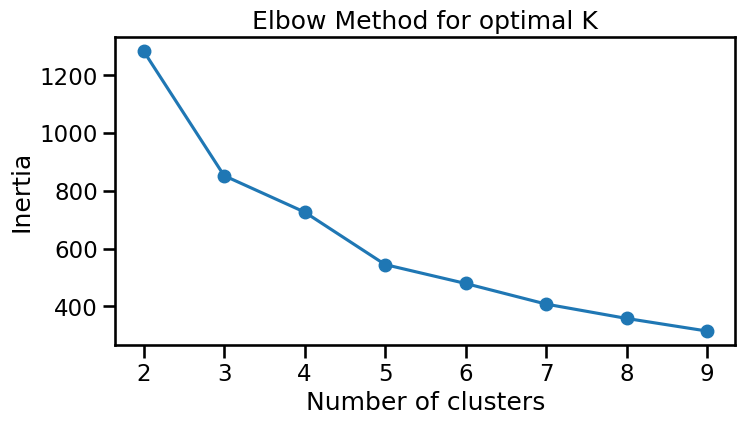

In [104]:
plt.figure(figsize = (8,4))
plt.plot(range(2,10),inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for optimal K")
plt.show()

In [110]:
kmeans= KMeans(n_clusters=4,random_state=42)
customer_cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [112]:
customer_cluster_df.head()

,CustomerName,Total_Revenue,Total_Profit,Avg_Profit_margin,Total_order,Total_Item,Avg_Order_value,Cluster
0,Adams,31837.0,27570.95,66.152452,3,50.0,15653.928571,1
1,Aguilar,5506.0,4204.04,62.948925,1,26.0,5506.000000,0
2,Alexander,234.0,183.00,78.205128,1,3.0,234.000000,0
3,Allen,15306.0,13386.97,65.652516,3,24.0,7486.400000,2
4,Alvarado,76.0,32.00,42.105263,1,2.0,76.000000,0


In [116]:
#select only numberic columns
numeric_cols= customer_cluster_df.select_dtypes(include="number")
cluster_profit =(
    numeric_cols
    .groupby(customer_cluster_df["Cluster"])
    .mean()
    .round(2)
)
cluster_profit

,Total_Revenue,Total_Profit,Avg_Profit_margin,Total_order,Total_Item,Avg_Order_value,Cluster
Cluster,,,,,,,
0,3118.49,2423.10,61.91,1.06,10.31,3082.01,0.0
1,30241.77,25366.17,69.00,2.58,55.50,18895.98,1.0
2,7986.14,6408.13,65.65,2.51,26.46,4270.84,2.0
3,178895.00,163236.05,71.40,1.50,111.00,144061.89,3.0


In [138]:
cluster_summary = (
            customer_cluster_df
            .groupby("Cluster")
            .agg(
                Customer_Count=("CustomerName","count"),
                Avg_Revenue=("Total_Revenue","mean"),
                Avg_Profit=("Total_Profit", "mean"),
                Avg_Orders=("Total_order", "mean"),
                Avg_Margin=("Avg_Profit_margin","mean")
             )
             .round(2)
)

cluster_summary

,Customer_Count,Avg_Revenue,Avg_Profit,Avg_Orders,Avg_Margin
Cluster,,,,,
0,236,3118.49,2423.10,1.06,61.91
1,26,30241.77,25366.17,2.58,69.00
2,72,7986.14,6408.13,2.51,65.65
3,2,178895.00,163236.05,1.50,71.40
